# **Visualisation 6**

### Imports

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import matplotlib.pyplot as plt
import pandas as pd

from src.aggregator import DataAggregator

from src.visualization import _create_multiple_residues_df

In [ ]:
country_list = [
    "AT",
    "CY",
    "CZ",
    "DE",
    "DK",
    "ES",
    "FR",
    "GR",
    "IE",
    "LU",
    "LV",
    "MT",
    "NO",
    "PL",
    "RO",
    "SE",
    "SI",
    "SK",
    "IT",
    "NL",
    "FI",
]

new_country_list = [
    "BE",
    "BA",
    "BG",
    "HR",
    "EE",
    "HU",
    "PT",
    "GB",
    "LT",
    "IS",
    "ME",
    "XI",
    "MK",
]

full_country_list = country_list + new_country_list

year_list = list(range(2011, 2025))

exception_list = [
    ("BA", 2011),
    ("BA", 2012),
    ("BA", 2013),
    ("BA", 2014),
    ("BA", 2015),
    ("BA", 2016),
    ("HR", 2011),
    ("HR", 2012),
    ("HR", 2013),
    ("GB", 2021),
    ("GB", 2022),
    ("GB", 2023),
    ("ME", 2011),
    ("ME", 2012),
    ("ME", 2013),
    ("ME", 2014),
    ("ME", 2015),
    ("ME", 2016),
    ("XI", 2011),
    ("XI", 2012),
    ("XI", 2013),
    ("XI", 2014),
    ("XI", 2015),
    ("XI", 2016),
    ("XI", 2017),
    ("XI", 2018),
    ("XI", 2019),
    ("XI", 2020),
    ("MK", 2011),
    ("MK", 2012),
    ("MK", 2013),
    ("MK", 2014),
    ("MK", 2015),
    ("MK", 2016),
    ("HU", 2024),
    ("BA", 2024),
    ("GB", 2024),
]

COLOR_BUTTER = "#023E8A"
COLOR_MILK = "#5A189A"

In [ ]:
aggregator = DataAggregator(
    data_dir="../data/merged/final_dataset.pkl",
    milk_dir="../data/merged/milk_mod.pkl",
    butter_dir="../data/merged/butter.pkl",
)

In [10]:
df_milk = aggregator.milk_dataframe

In [ ]:
df_butter = aggregator.butter_dataframe

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def plot_multiple_residues_bar(df, product="butter"):
    years = sorted(df["year"].unique())

    max_pesticides = int(df["pesticideCount"].max())
    max_pesticides = max(7, max_pesticides)
    all_pesticide_counts = pd.DataFrame(
        {"pesticideCount": range(max_pesticides + 1)}
    )

    rows = max(1, int(np.ceil(len(years) / 2)))
    fig, axes = plt.subplots(rows, 2, figsize=(14, rows * 5), squeeze=False)

    labels = [
        "(a)",
        "(b)",
        "(c)",
        "(d)",
        "(e)",
        "(f)",
        "(g)",
        "(h)",
        "(i)",
        "(j)",
        "(k)",
        "(l)",
        "(m)",
        "(o)",
    ]

    for i, ax in enumerate(axes.flat):
        if i < len(years):
            year = years[i]
            data_year = df[df["year"] == year]

            data = pd.merge(
                all_pesticide_counts, data_year, on="pesticideCount", how="left"
            )
            data["sampleCount"] = data["sampleCount"].fillna(0)
            data["percentage"] = data["percentage"].fillna(0)

            bar_color = "#023E8A" if product == "butter" else "#5A189A"

            tick_labels = [
                f"{int(row['pesticideCount'])}\n(n={int(row['sampleCount'])})"
                for _, row in data.iterrows()
            ]

            ax.bar(
                data["pesticideCount"],
                data["percentage"],
                color=bar_color,
                width=0.8,
            )

            ax.set_xticks(data["pesticideCount"])
            ax.set_xticklabels(tick_labels, fontsize=9)

            total_samples = int(data["sampleCount"].sum())
            ax.set_title(
                f"{labels[i]} Year: {year}\nTotal samples: {total_samples}"
            )
            ax.set_xlabel("Number of pesticides")
            ax.set_ylabel("Percentage (%) of all samples tested")
        else:
            ax.axis("off")

    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()

In [ ]:
df_6_milk = pd.read_csv("../results/results/6_number_of_pesticides_milk.csv")
df_6_butter = pd.read_csv(
    "../results/results/6_number_of_pesticides_butter.csv"
)

# anomalies removal
df_6_butter = df_6_butter[df_6_butter["pesticideCount"] <= 5]

year_mask = df_6_butter["year"] == 2011

df_6_butter.loc[year_mask, "totalSamplesCount"] -= 15
df_6_butter.loc[year_mask, "percentage"] = (
    df_6_butter.loc[year_mask, "sampleCount"]
    / df_6_butter.loc[year_mask, "totalSamplesCount"]
    * 100
).round(2)

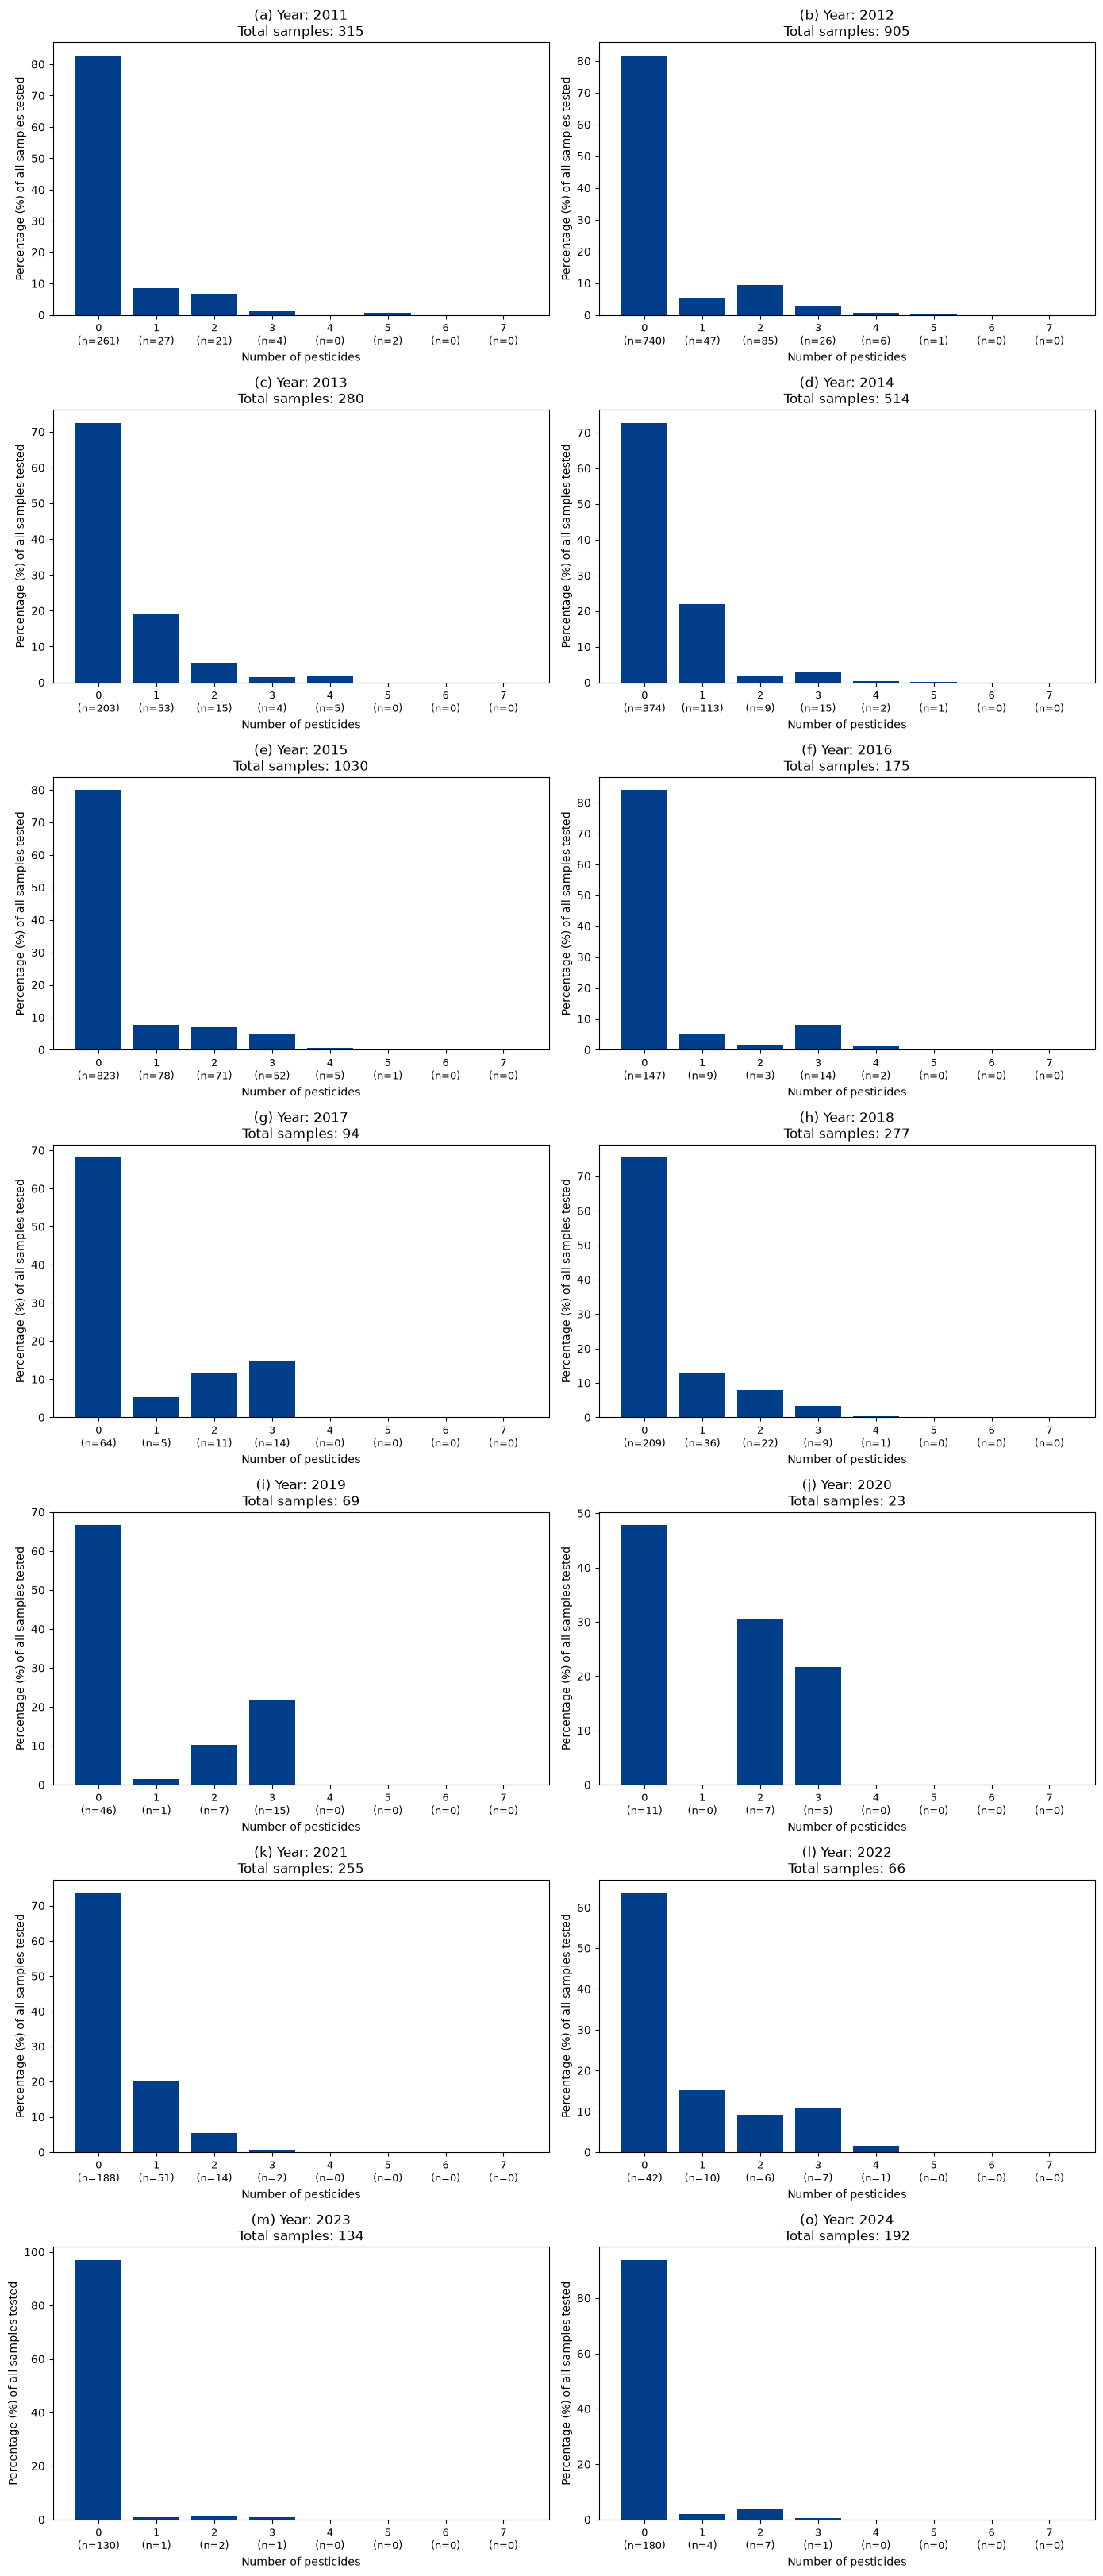

In [34]:
plot_multiple_residues_bar(df_6_butter, product="butter")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


def plot_multiple_residues_pie(df, product="butter"):
    """
    Generuje wykresy kołowe dla poszczególnych lat.
    Uwzględnia wyłącznie próbki z co najmniej 1 pestycydem.
    """
    df_pie = df[(df["pesticideCount"] >= 1) & (df["sampleCount"] > 0)].copy()

    if df_pie.empty:
        print(
            f"Brak pozytywnych próbek (>=1 pestycydu) dla wybranego zestawu danych."
        )
        return

    df_pie["percentage_pie"] = df_pie.groupby("year")["sampleCount"].transform(
        lambda x: x / x.sum() * 100
    )

    years = sorted(df_pie["year"].unique())

    cols = 3
    rows = max(1, int(np.ceil(len(years) / cols)))
    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5), squeeze=False)

    labels = [
        "(a)",
        "(b)",
        "(c)",
        "(d)",
        "(e)",
        "(f)",
        "(g)",
        "(h)",
        "(i)",
        "(j)",
        "(k)",
        "(l)",
        "(m)",
        "(o)",
    ]

    if product == "butter":
        cmap = LinearSegmentedColormap.from_list(
            "custom_blue", ["#E0FBFC", "#023E8A"]
        )
    else:
        cmap = LinearSegmentedColormap.from_list(
            "custom_purple", ["#FDE2F3", "#5A189A"]
        )

    # KROK 4: Rysowanie wykresów w pętli
    for i, ax in enumerate(axes.flat):
        if i < len(years):
            year = years[i]
            data = df_pie[df_pie["year"] == year]

            if data.empty:
                ax.axis("off")
                continue

            sizes = data["percentage_pie"]
            labels_pie = [
                f"{int(row['pesticideCount'])}\n({int(row['sampleCount'])})"
                for _, row in data.iterrows()
            ]

            vmin = data["pesticideCount"].min()
            vmax = data["pesticideCount"].max()

            if vmin == vmax:
                norm = plt.Normalize(vmin - 1, vmax)
            else:
                norm = plt.Normalize(vmin, vmax)

            colors = [cmap(norm(n)) for n in data["pesticideCount"]]

            wedges, texts, autotexts = ax.pie(
                sizes,
                labels=labels_pie,
                colors=colors,
                autopct="%1.1f%%",
                startangle=90,
                textprops={"fontsize": 12},
            )

            total_samples = int(data["sampleCount"].sum())
            ax.set_title(
                f"{labels[i]} Year: {year}\nTotal positive samples: {total_samples}"
            )
        else:
            ax.axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

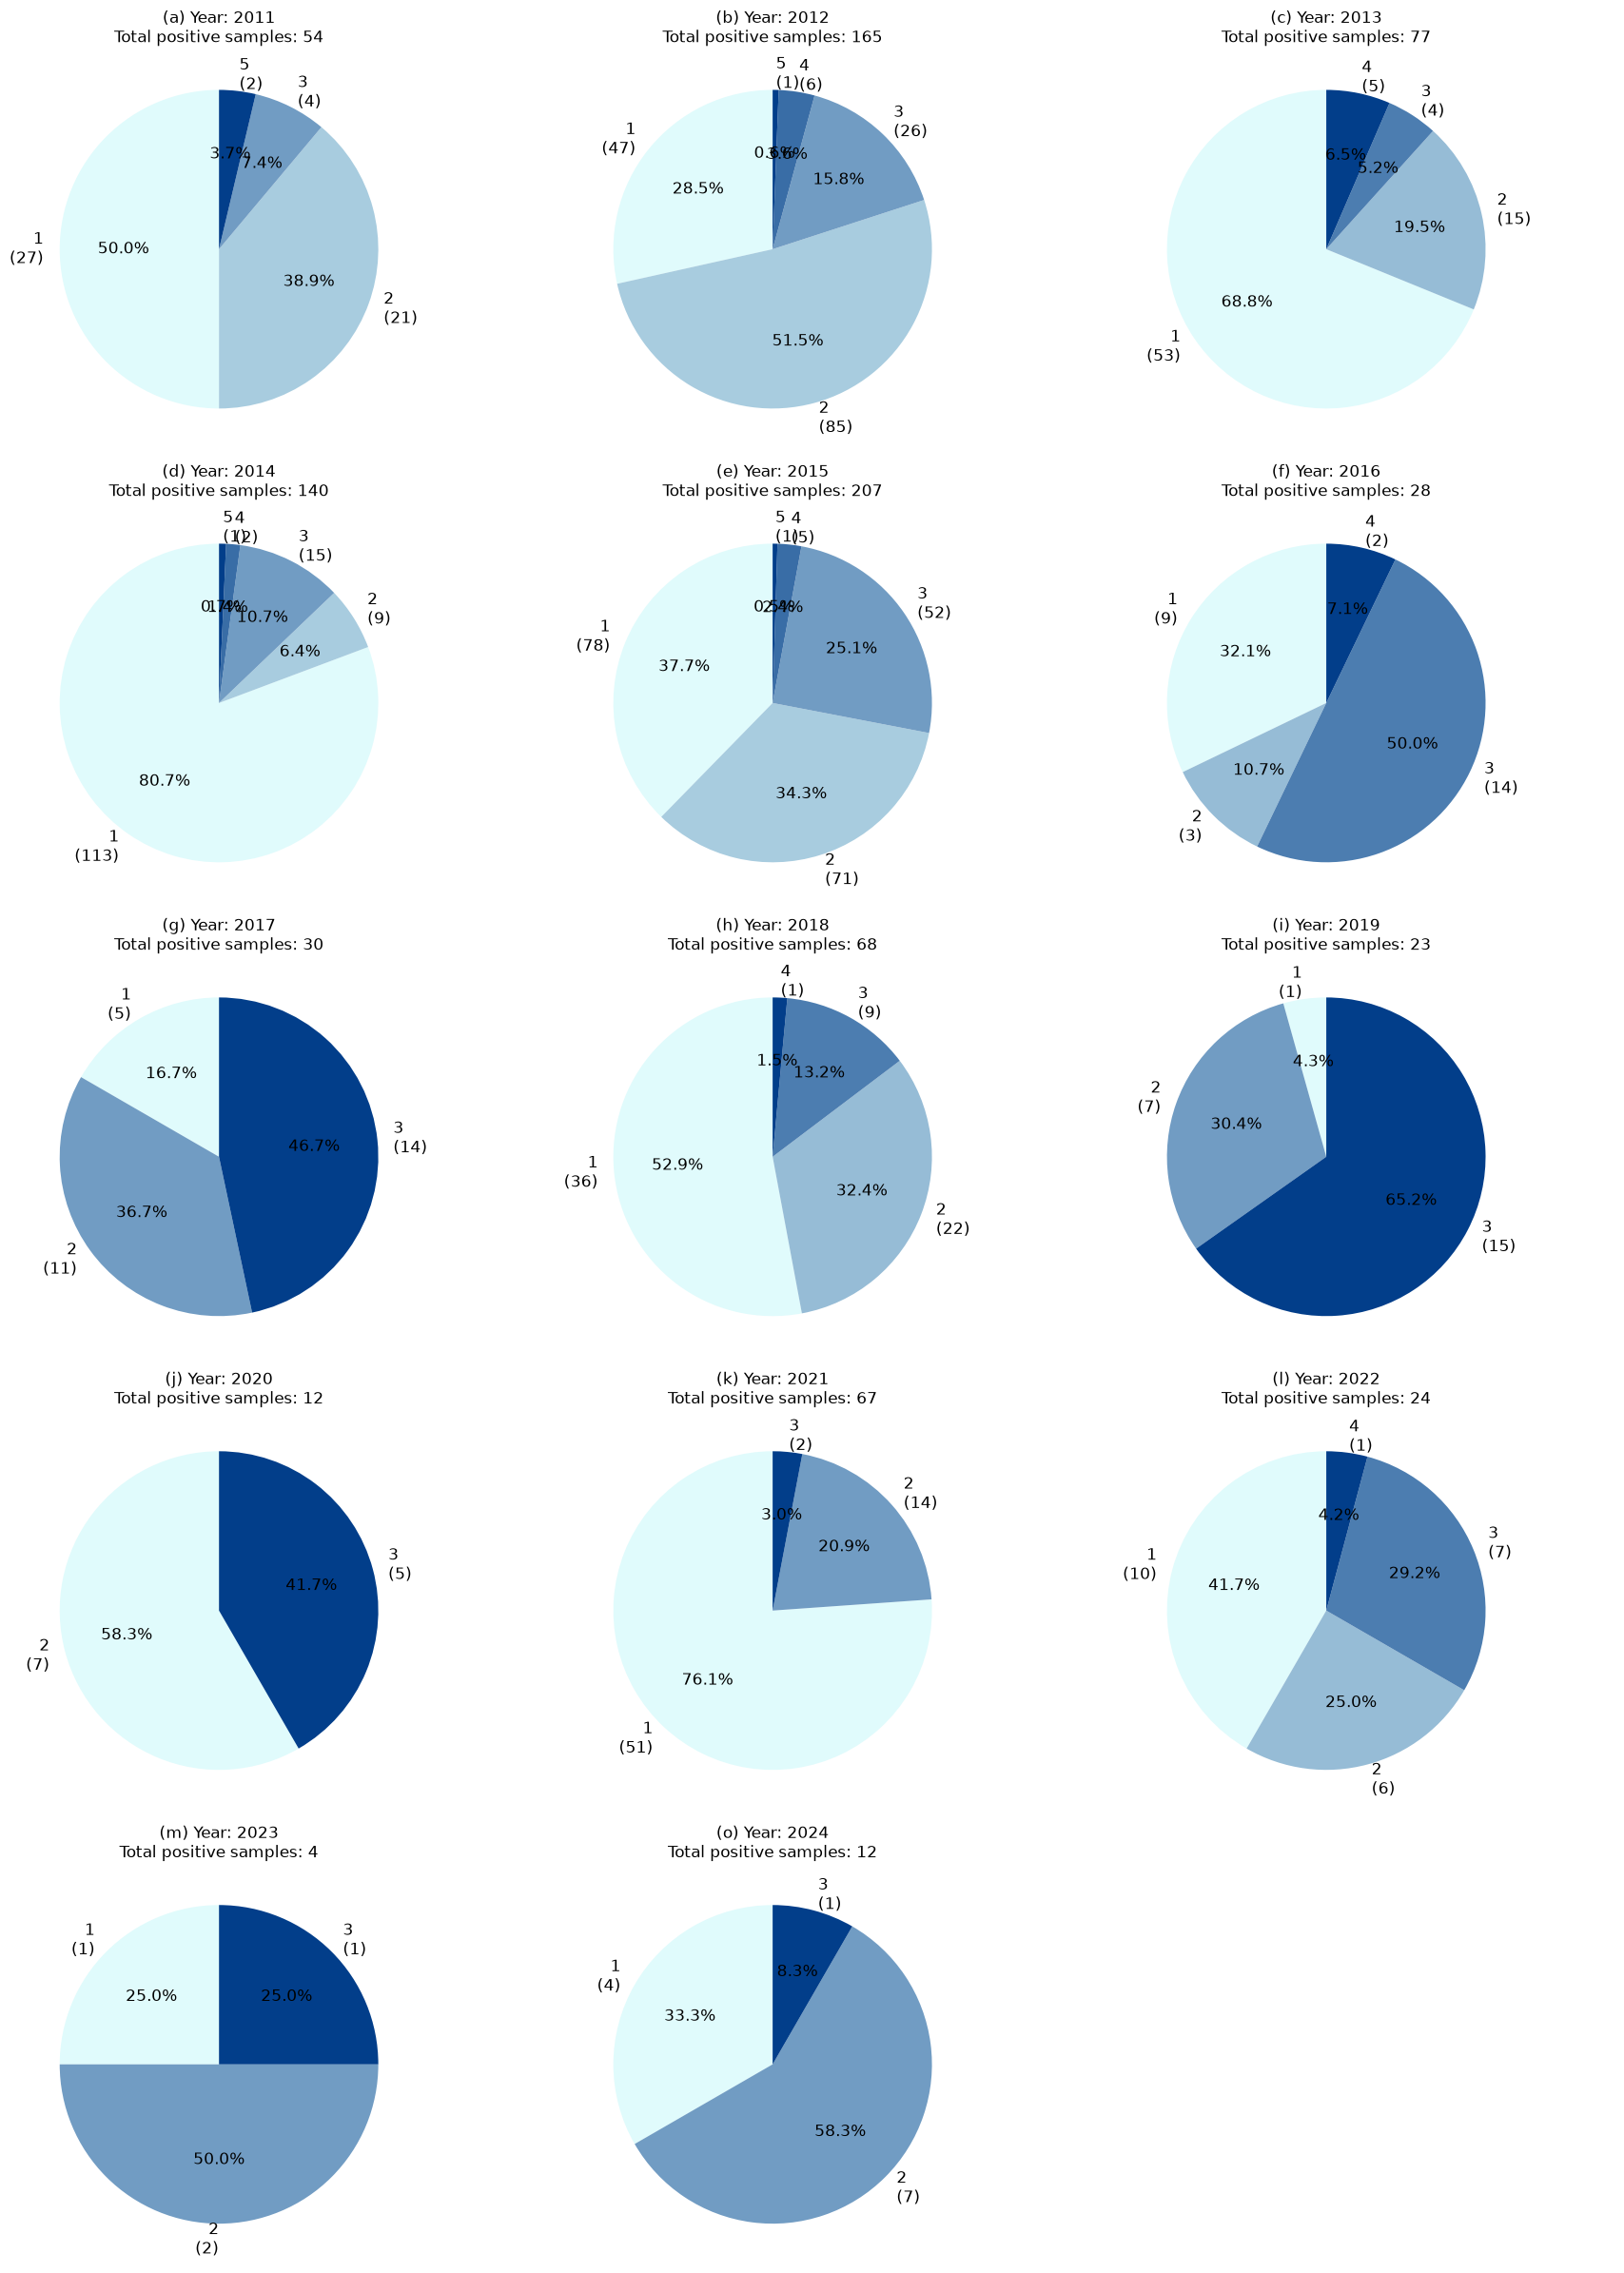

In [36]:
plot_multiple_residues_pie(df_6_butter, product="butter")